# Evaluate Vision Transformer

In [20]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)      # Auto-adjust width
pd.set_option('display.max_colwidth', None)  # No truncation

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("model/vit.csv")

y_true = df['ground_truth']
y_pred = df['prediction']
y_img = df["image"]

le = LabelEncoder()
y_true_enc = le.fit_transform(y_true)
y_pred_enc = le.transform(y_pred)

print(f"{len(le.classes_)} Classes: {le.classes_}")
print(f"Test set size: {len(y_true)}")

107 Classes: ['Albania' 'American Samoa' 'Andorra' 'Argentina' 'Australia' 'Austria'
 'Bangladesh' 'Belgium' 'Bhutan' 'Bolivia, Plurinational State of'
 'Botswana' 'Brazil' 'Bulgaria' 'Cambodia' 'Canada' 'Chile'
 'Christmas Island' 'Colombia' 'Croatia' 'Curaçao' 'Czechia' 'Denmark'
 'Dominican Republic' 'Ecuador' 'Estonia' 'Eswatini' 'Faroe Islands'
 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Greenland' 'Guam'
 'Guatemala' 'Hong Kong' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Ireland'
 'Isle of Man' 'Israel' 'Italy' 'Japan' 'Jersey' 'Jordan' 'Kazakhstan'
 'Kenya' 'Korea, Republic of' 'Kyrgyzstan'
 "Lao People's Democratic Republic" 'Latvia' 'Lebanon' 'Lesotho'
 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Macao' 'Malaysia' 'Malta'
 'Mexico' 'Mongolia' 'Montenegro' 'Namibia' 'Nepal' 'Netherlands'
 'New Zealand' 'Nigeria' 'North Macedonia' 'Northern Mariana Islands'
 'Norway' 'Oman' 'Panama' 'Peru' 'Philippines' 'Poland' 'Portugal'
 'Puerto Rico' 'Qatar' 'Romania' 'Russian Federation' 'R

## Core Metrics

### Accuracy, Recall, F1-Score of whole inferenced data

- macro = average over classes (treat all classes equally)
- weighted = average weighted by class support
- micro = global TP/FP/FN over all classes

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_macro = precision_score(y_true_enc, y_pred_enc, average='macro')
recall_macro    = recall_score(y_true_enc, y_pred_enc, average='macro')
f1_macro        = f1_score(y_true_enc, y_pred_enc, average='macro')

precision_weighted = precision_score(y_true_enc, y_pred_enc, average='weighted')
recall_weighted    = recall_score(y_true_enc, y_pred_enc, average='weighted')
f1_weighted        = f1_score(y_true_enc, y_pred_enc, average='weighted')

precision_micro = precision_score(y_true_enc, y_pred_enc, average='micro')
recall_micro    = recall_score(y_true_enc, y_pred_enc, average='micro')
f1_micro        = f1_score(y_true_enc, y_pred_enc, average='micro')

print("Macro:")
print(f"Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
print("Weighted:")
print(f"Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")
print("Micro:")
print(f"Precision: {precision_micro:.4f}, Recall: {recall_micro:.4f}, F1: {f1_micro:.4f}")

Macro:
Precision: 0.7583, Recall: 0.7452, F1: 0.7434
Weighted:
Precision: 0.7330, Recall: 0.7235, F1: 0.7208
Micro:
Precision: 0.7235, Recall: 0.7235, F1: 0.7235


### Mathews Correlation Coefficient

= Classification quality across all confusion matrix elements

- Better than accuracy or F1 in multi-class geographic tasks because it detects when models perform well on majority countries but fail minorities
- Higher MCC = Captures global patterns better

In [23]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_true_enc, y_pred_enc) 
print(f"MCC: {mcc:.4f}")

MCC: 0.7203


## Per-Class Analysis

### Classification Report with Precision, Recall, F1-score per class

In [24]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)

class_metrics = pd.DataFrame({
    'Country': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'Support': support
}).round(4)

print(class_metrics.sort_values('F1', ascending=False))

                              Country  Precision  Recall      F1  Support
84              Sao Tome and Principe     0.9778  0.9462  0.9617       93
106                     Åland Islands     0.9505  0.9600  0.9552      100
32                          Greenland     0.9406  0.9694  0.9548       98
50                         Kyrgyzstan     0.9423  0.9608  0.9515      102
54                            Lesotho     0.9333  0.9608  0.9469      102
58                              Macao     0.8850  1.0000  0.9390      100
53                            Lebanon     0.9655  0.9032  0.9333       93
96                            Tunisia     0.8909  0.9703  0.9289      101
26                      Faroe Islands     0.9286  0.9100  0.9192      100
33                               Guam     0.9375  0.9000  0.9184      100
55                      Liechtenstein     0.9020  0.9293  0.9154       99
98                             Uganda     0.9286  0.9010  0.9146      101
19                            Curaçao 

Every country should have at least a F1-Score of 0.5 -> try to improve these countries

In [25]:
poor_performers = class_metrics[class_metrics['F1'] < 0.5].sort_values('F1')

print(poor_performers)

     Country  Precision  Recall      F1  Support
7    Belgium     0.6098  0.2451  0.3497      102
28    France     0.5319  0.4167  0.4673      300
89  Slovenia     0.5970  0.3960  0.4762      101
97   Türkiye     0.6533  0.3769  0.4780      130
61    Mexico     0.4262  0.5493  0.4800      142


### Visualization of F1-Scores per Country

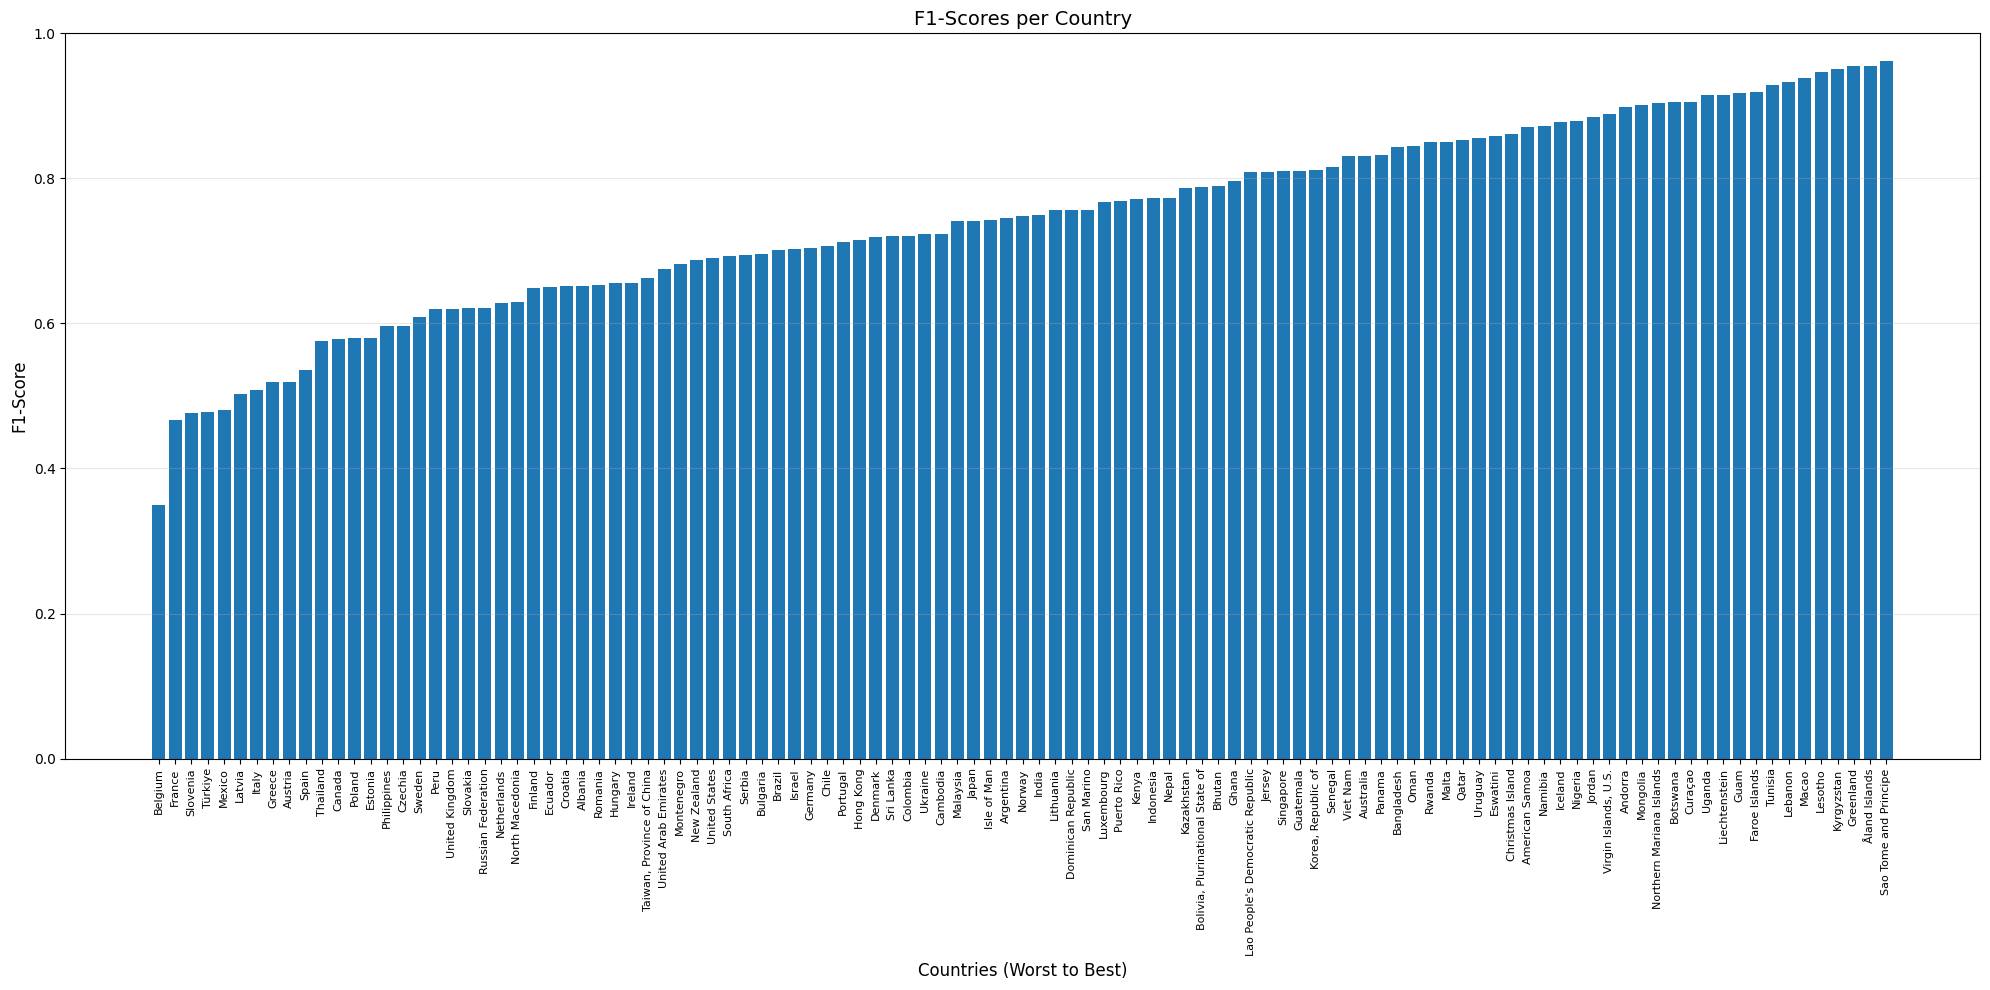

In [26]:
import matplotlib.pyplot as plt

f1_sorted = class_metrics.sort_values('F1')

plt.figure(figsize=(20, 10))
bars = plt.bar(range(len(f1_sorted)), f1_sorted['F1'])
plt.xlabel('Countries (Worst to Best)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Scores per Country', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.xticks(range(len(f1_sorted)), f1_sorted['Country'], rotation=90, fontsize=8, ha='center')

plt.tight_layout()
plt.show()

### Visualization of Best/Worst 5 Countries by F1

Fluctuation of metrics for worst classes could be:

- Model is uncertain -> classes get confused often
- Features overlap between classes
- Around 100 samples per class -> low amount of samples
- Fluctuate more than ResNet because they rely on more data

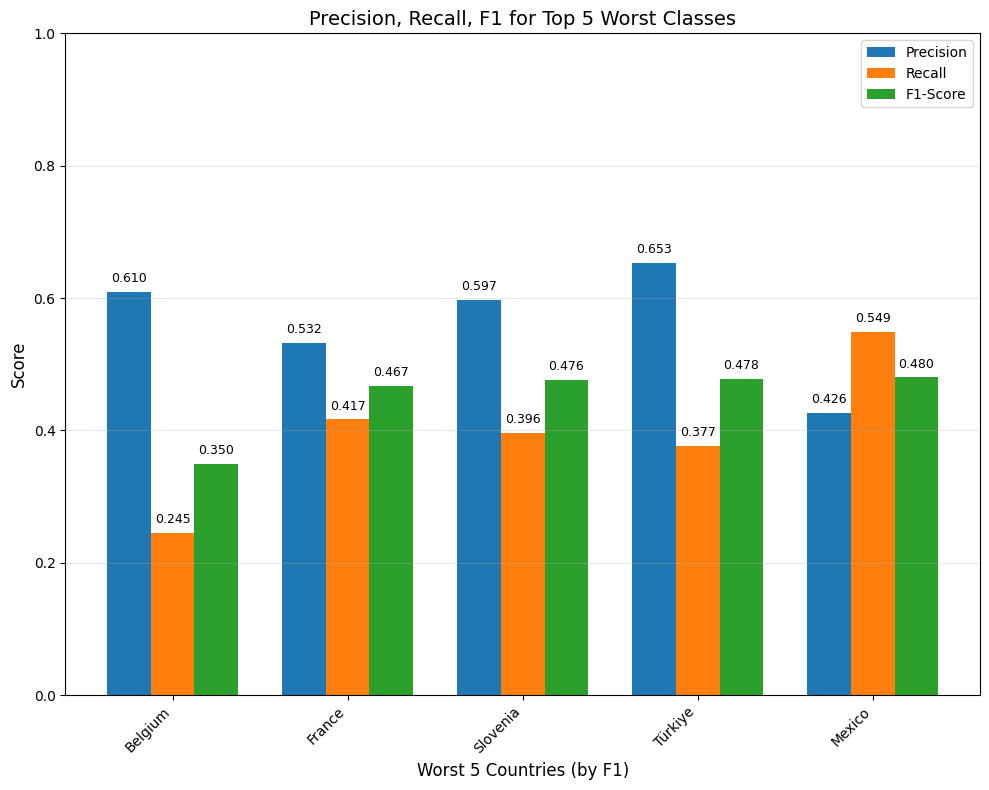

In [27]:
import matplotlib.pyplot as plt
import numpy as np

worst_5 = class_metrics.nsmallest(5, 'F1')

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(worst_5))
width = 0.25

bars1 = ax.bar(x - width, worst_5['Precision'], width, label='Precision')
bars2 = ax.bar(x, worst_5['Recall'], width, label='Recall')
bars3 = ax.bar(x + width, worst_5['F1'], width, label='F1-Score',)

ax.set_xlabel('Worst 5 Countries (by F1)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, F1 for Top 5 Worst Classes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(worst_5['Country'], rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


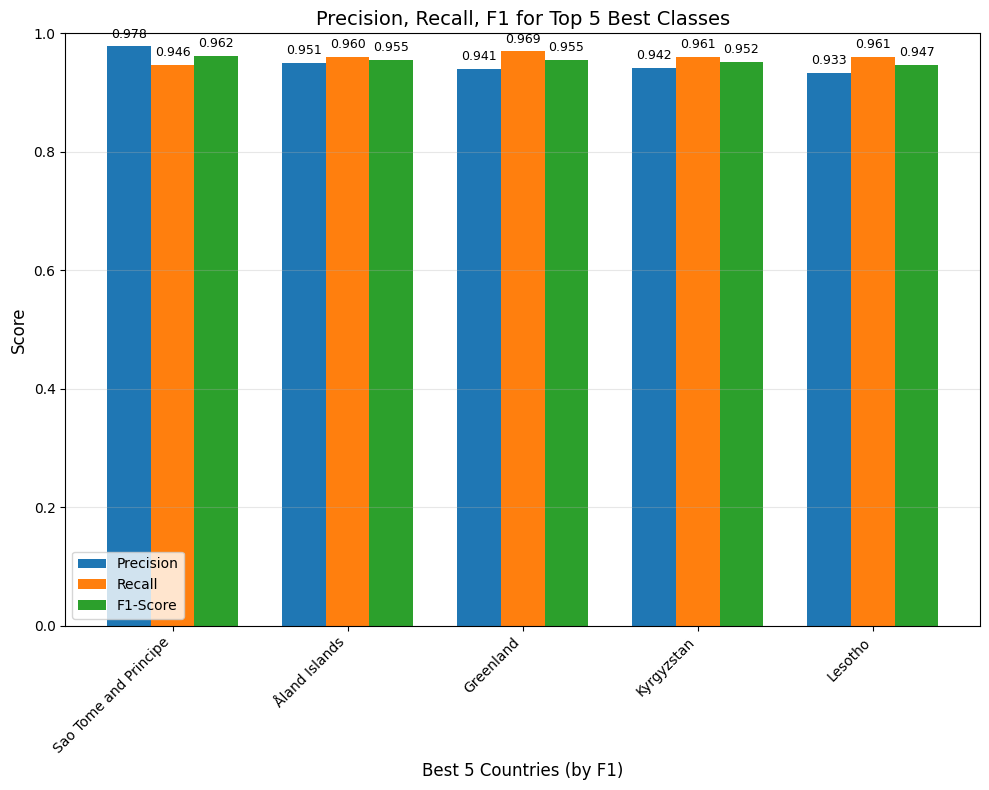

In [28]:
import matplotlib.pyplot as plt
import numpy as np

best_5 = class_metrics.nlargest(5, 'F1')

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(best_5))
width = 0.25

bars1 = ax.bar(x - width, best_5['Precision'], width, label='Precision')
bars2 = ax.bar(x, best_5['Recall'], width, label='Recall')
bars3 = ax.bar(x + width, best_5['F1'], width, label='F1-Score',)

ax.set_xlabel('Best 5 Countries (by F1)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, F1 for Top 5 Best Classes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(best_5['Country'], rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Confusion Matrix of all countries

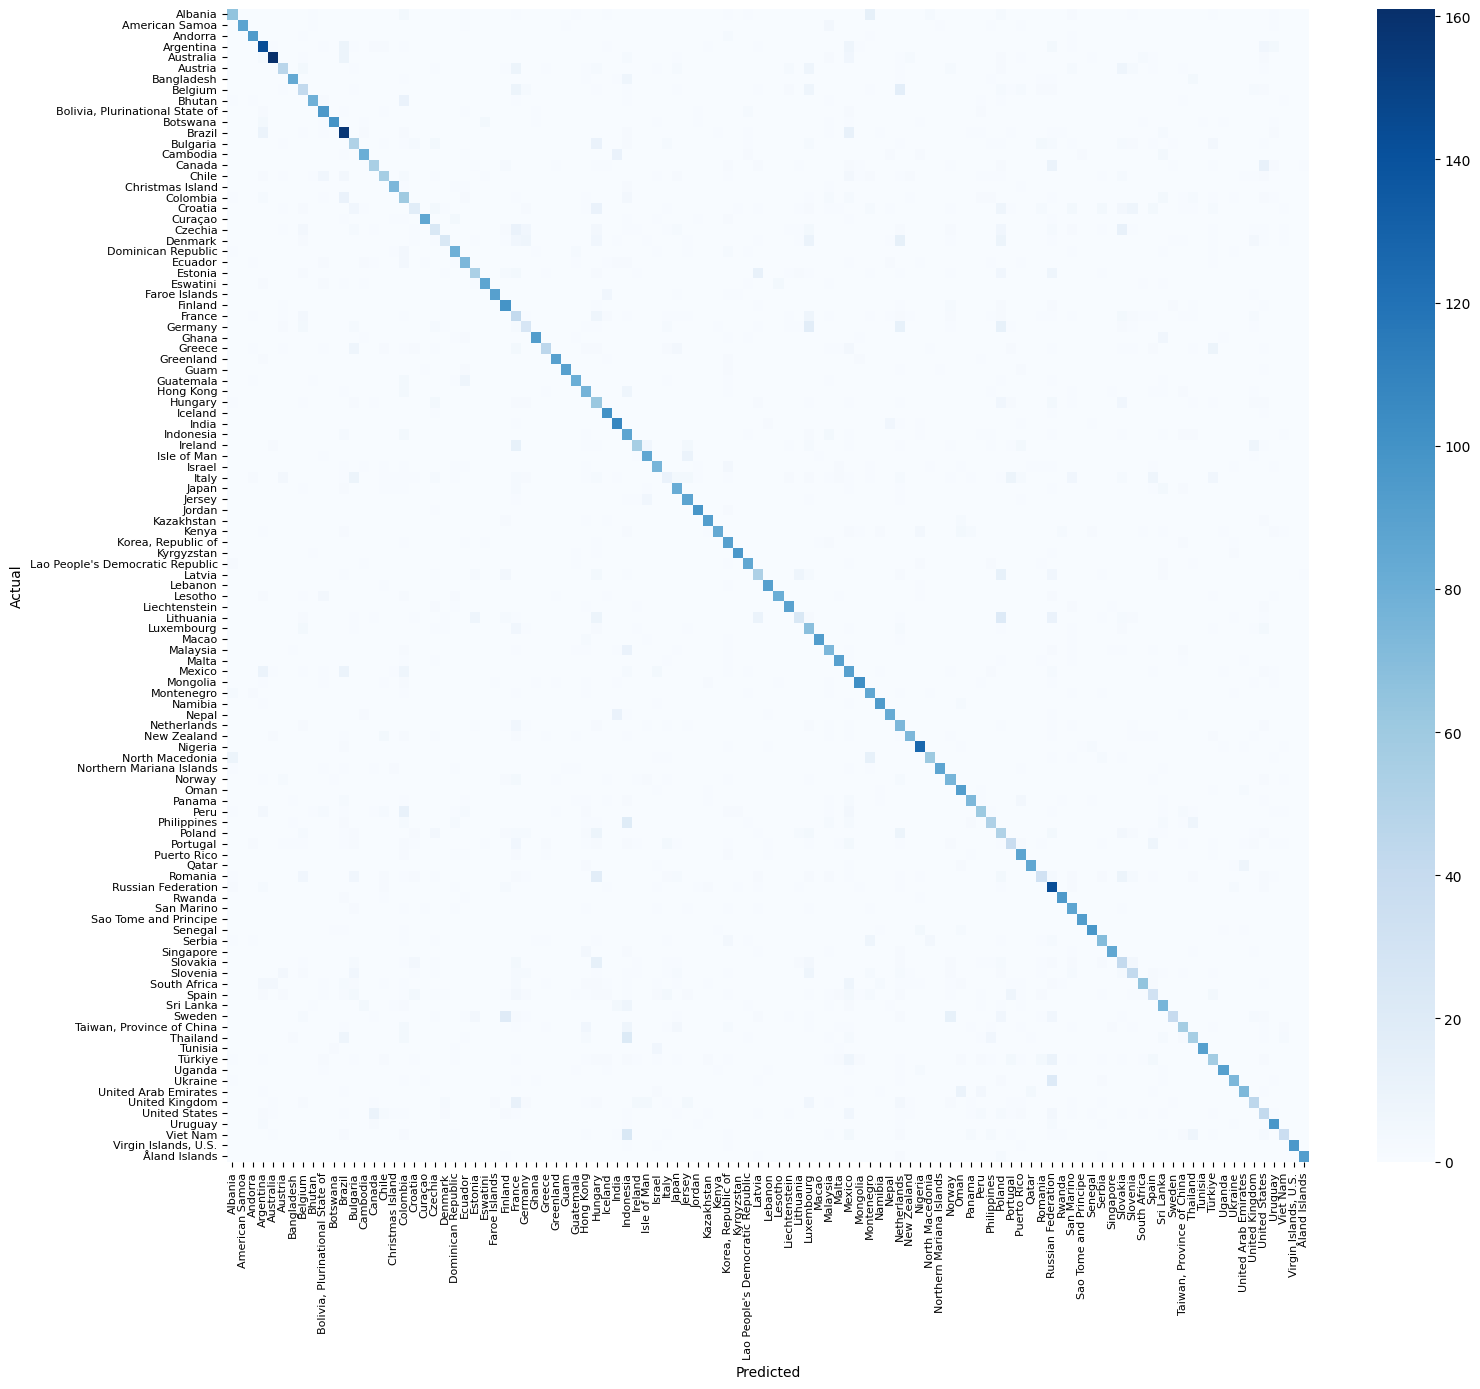

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_enc, y_pred_enc)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Most common Missclassification

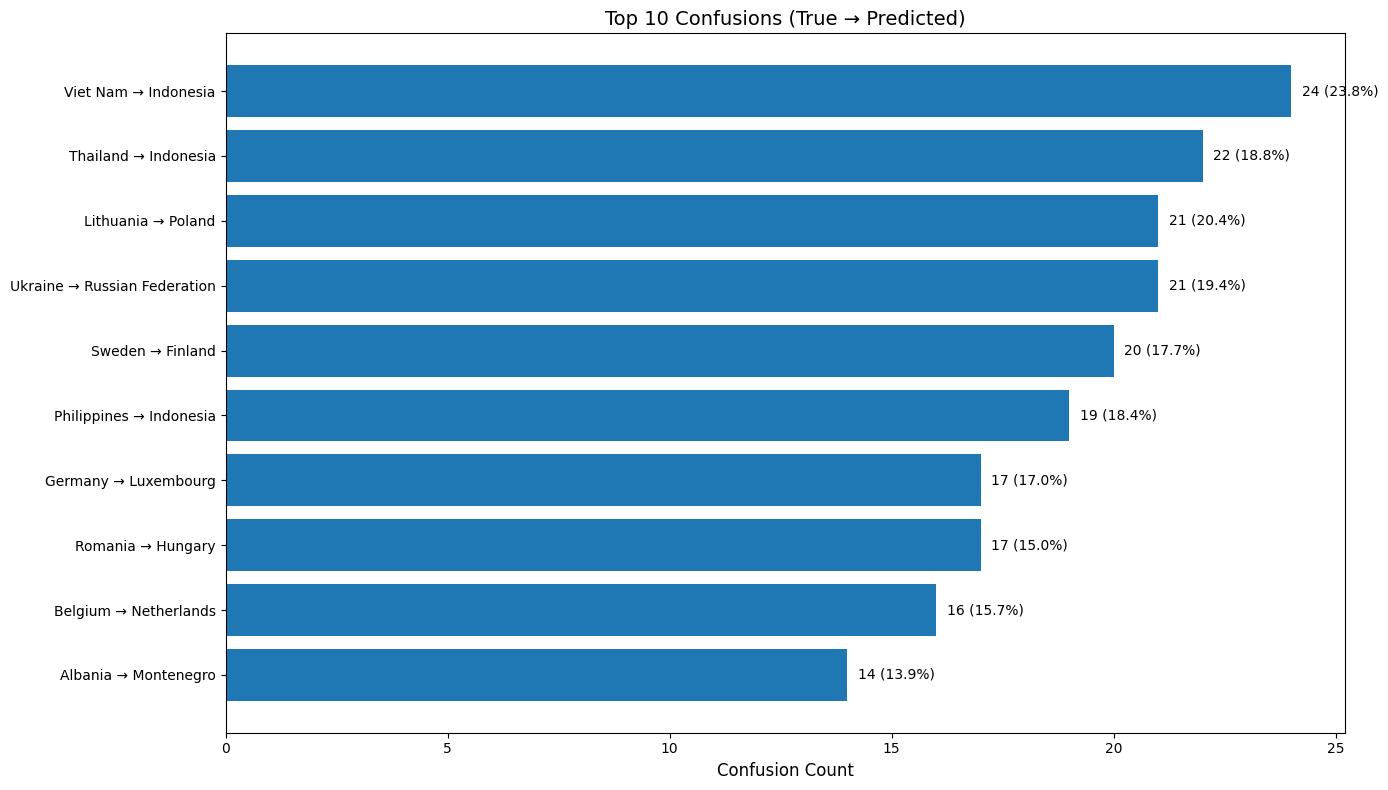

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

conf_pairs = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i,j] > 0:
            conf_pairs.append({
                'True': le.classes_[i], 
                'Pred': le.classes_[j], 
                'Count': cm[i,j],
                'Error_%': cm[i,j]/cm.sum(axis=1)[i]
            })

top_confusions = pd.DataFrame(conf_pairs).nlargest(10, 'Count')

plt.figure(figsize=(14, 8))

bars = plt.barh(len(top_confusions)-1 - np.arange(len(top_confusions)), top_confusions['Count'])
plt.yticks(len(top_confusions)-1 - np.arange(len(top_confusions)), 
           [f"{row['True']} → {row['Pred']}" for _, row in top_confusions.iterrows()], 
           fontsize=10)
plt.xlabel('Confusion Count', fontsize=12)
plt.title('Top 10 Confusions (True → Predicted)', fontsize=14)

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + max(top_confusions['Count'])*0.01, bar.get_y() + bar.get_height()/2, 
             f'{top_confusions["Count"].iloc[i]} ({top_confusions["Error_%"].iloc[i]:.1%})',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Grad-CAM Visualizations

Visualize the Grad-CAM heatmap only for the missclassified images

In [12]:
import pandas as pd
import os
import pycountry
from pathlib import Path

COUNTRY = "Italy"
country_mask = y_true == COUNTRY
country_wrong_mask = (y_true == COUNTRY) & (y_true != y_pred)

wrong_images = df[country_wrong_mask].copy()

wrong_images["path"] = wrong_images.apply(lambda row: os.path.join("data", pycountry.countries.search_fuzzy(row["ground_truth"])[0].alpha_2, row["image"]), axis=1)
wrong_images.describe()

,image,ground_truth,prediction,path
count,95,95,95,95
unique,95,1,35,95
top,0107.jpg,Italy,Portugal,data/IT/0107.jpg
freq,1,95,9,1


In [13]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
import torch
from src.model import ViTModel

checkpoint = torch.load('model/ViTModel//best.pth')
model = ViTModel(num_classes=len(checkpoint["label_map"]))
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)

/home/jovyan/CountryGuessr/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


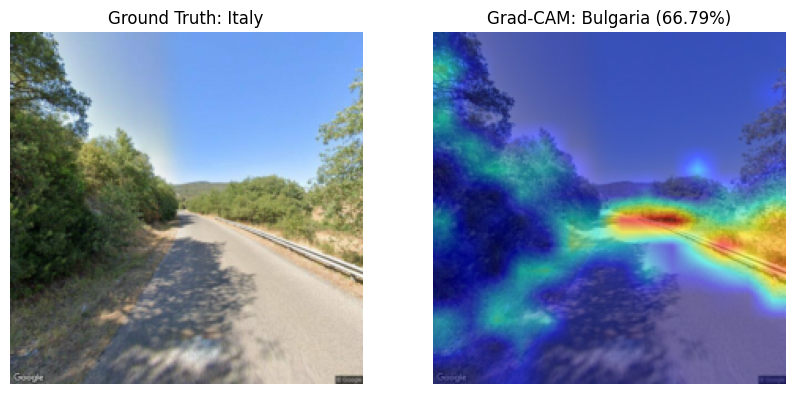

Predicted probabilities:
Bulgaria: 66.79%
Hungary: 15.92%
Mexico: 7.88%
Argentina: 2.30%
Slovakia: 1.18%


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from torchvision import transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

label_map = checkpoint["label_map"]
idx_to_name = {v: k for k, v in label_map.items()}

from PIL import Image

def load_image_from_df(df, idx, transform):
    image_path = df.iloc[idx]["path"]
    gt_name = df.iloc[idx]["ground_truth"]

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    label = label_map[gt_name]

    return image, label, image_path

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor()
])

target_layers = [model.vit.blocks[-1].norm1]

# idx = random.randint(0, len(wrong_images) - 1)
idx = 51
top_k = 5

model.eval()

image, label, image_path = load_image_from_df(wrong_images, idx, transform)
image_tensor = image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]

topk_indices = probabilities.argsort()[-top_k:][::-1]
topk_probs = probabilities[topk_indices]
topk_countries = [idx_to_name[i] for i in topk_indices]

gt_country = idx_to_name[label]

cam = GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

targets = [ClassifierOutputTarget(topk_indices[0])]

grayscale_cam = cam(
    input_tensor=image_tensor,
    targets=targets,
)[0]

input_image = image.permute(1, 2, 0).cpu().numpy()
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

cam_image = show_cam_on_image(
    input_image,
    grayscale_cam,
    use_rgb=True
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(input_image)
axs[0].axis("off")
axs[0].set_title(f"Ground Truth: {gt_country}")

axs[1].imshow(cam_image)
axs[1].axis("off")
axs[1].set_title(f"Grad-CAM: {topk_countries[0]} ({topk_probs[0]*100:.2f}%)")

plt.show()

print("Predicted probabilities:")
for country, prob in zip(topk_countries, topk_probs):
    print(f"{country}: {prob*100:.2f}%")